# Imports et configuration


In [8]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("🚀 Projet 10 - Application de recommandation de contenu")


🚀 Projet 10 - Application de recommandation de contenu


# I. Setup et chargement des données


In [9]:
# Définition des chemins
DATA_DIR = "../Data/news-portal-user-interactions-by-globocom"
GENERATED_DIR = "../Generated"
os.makedirs(GENERATED_DIR, exist_ok=True)
METADATA_PATH = os.path.join(DATA_DIR, "articles_metadata.csv")
CLICKS_SAMPLE_PATH = os.path.join(DATA_DIR, "clicks_sample.csv")
EMBEDDINGS_PATH = os.path.join(DATA_DIR, "articles_embeddings.pickle")
OUTPUT_EMBEDDINGS_PATH = os.path.join(GENERATED_DIR, "articles_embeddings_pca.pickle")

# Chargement des fichiers
print("📂 Chargement des fichiers...")
clicks_df = pd.read_csv(CLICKS_SAMPLE_PATH)
articles_df = pd.read_csv(METADATA_PATH)
with open(EMBEDDINGS_PATH, 'rb') as f:
    embeddings = pickle.load(f)
print(f"✅ Clicks sample: {clicks_df.shape}")
print(f"✅ Articles metadata: {articles_df.shape}")
print(f"✅ Embeddings: {embeddings.shape}")


📂 Chargement des fichiers...
✅ Clicks sample: (1883, 12)
✅ Articles metadata: (364047, 5)
✅ Embeddings: (364047, 250)


## 1. Sur le fichier `clicks_sample.csv` (interactions)


In [10]:
print(f"\n📊 CLICKS DATA:")
print(f"Shape: {clicks_df.shape}")
print(f"Colonnes: {list(clicks_df.columns)}")
print(f"Période: {pd.to_datetime(clicks_df['click_timestamp'], unit='ms').min()} - {pd.to_datetime(clicks_df['click_timestamp'], unit='ms').max()}")



📊 CLICKS DATA:
Shape: (1883, 12)
Colonnes: ['user_id', 'session_id', 'session_start', 'session_size', 'click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']
Période: 2017-10-01 03:00:00.026000 - 2017-10-03 02:35:54.157000


### 📝 Dictionnaire des variables (`clicks_sample.csv`)
- **`user_id`** : Identifiant unique de l'utilisateur.
- **`session_id`** : Identifiant unique de la session de navigation.
- **`session_start`** : Heure (timestamp en millisecondes) du début de la session.
- **`session_size`** : Nombre de clics (ou d'articles lus) effectués lors de cette session.
- **`click_article_id`** : Identifiant de l'article cliqué (permet de faire la jointure avec `articles_metadata.csv`).
- **`click_timestamp`** : Heure exacte (timestamp) du clic.
- **`click_environment`** : Type d'environnement (ex: web, application).
- **`click_deviceGroup`** : Famille d'appareils utilisés (ex: mobile, desktop, tablette).
- **`click_os`** : Système d'exploitation de l'appareil.
- **`click_country`** : Code du pays d'origine du clic.
- **`click_region`** : Code de la région géographique du clic.
- **`click_referrer_type`** : Source du trafic (canal de provenance, ex: moteur de recherche, direct, etc.).

In [11]:
n_users = clicks_df['user_id'].nunique()
n_articles_clicked = clicks_df['click_article_id'].nunique()
n_interactions = len(clicks_df)

print(f"\n📈 Statistiques générales:")
print(f"- Utilisateurs uniques: {n_users}")
print(f"- Articles uniques cliqués: {n_articles_clicked}")
print(f"- Interactions totales: {n_interactions}")
print(f"- Interactions par utilisateur (moyenne): {n_interactions/n_users:.2f}")



📈 Statistiques générales:
- Utilisateurs uniques: 707
- Articles uniques cliqués: 323
- Interactions totales: 1883
- Interactions par utilisateur (moyenne): 2.66


In [12]:

user_interactions = clicks_df['user_id'].value_counts()
print(f"\n📊 Distribution interactions par utilisateur:")
print(f"- Min: {user_interactions.min()}")
print(f"- Médiane: {user_interactions.median()}")
print(f"- Moyenne: {user_interactions.mean():.2f}")
print(f"- Max: {user_interactions.max()}")



📊 Distribution interactions par utilisateur:
- Min: 2
- Médiane: 2.0
- Moyenne: 2.66
- Max: 24


In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("📈 Visualisation 1: Distribution des interactions par utilisateur")

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Distribution des interactions", "Boxplot des interactions")
)

# Histogramme
fig.add_trace(go.Histogram(
    x=user_interactions.values,
    nbinsx=20,
    marker_color='#56B4E9',
    opacity=0.8,
    name='Interactions',
    showlegend=False
), row=1, col=1)

# Lignes de statistiques
fig.add_vline(x=user_interactions.median(), line_dash="dash", line_color="red", 
              annotation_text=f"Médiane: {user_interactions.median()}", annotation_position="top right", row=1, col=1)
fig.add_vline(x=user_interactions.mean(), line_dash="dash", line_color="green", 
              annotation_text=f"Moyenne: {user_interactions.mean():.2f}", annotation_position="top right", row=1, col=1)

# Boxplot
fig.add_trace(go.Box(
    y=user_interactions.values,
    name='Interactions',
    marker_color='#56B4E9',
    showlegend=False
), row=1, col=2)

# Mise en forme
fig.update_xaxes(title_text="Nombre d'interactions par utilisateur", row=1, col=1)
fig.update_yaxes(title_text="Nombre d'utilisateurs", row=1, col=1)
fig.update_yaxes(title_text="Nombre d'interactions", row=1, col=2)

fig.update_layout(height=500, width=1000, template="plotly_white")
fig.show()


📈 Visualisation 1: Distribution des interactions par utilisateur



📈 Visualisation 2: Articles les plus populaires


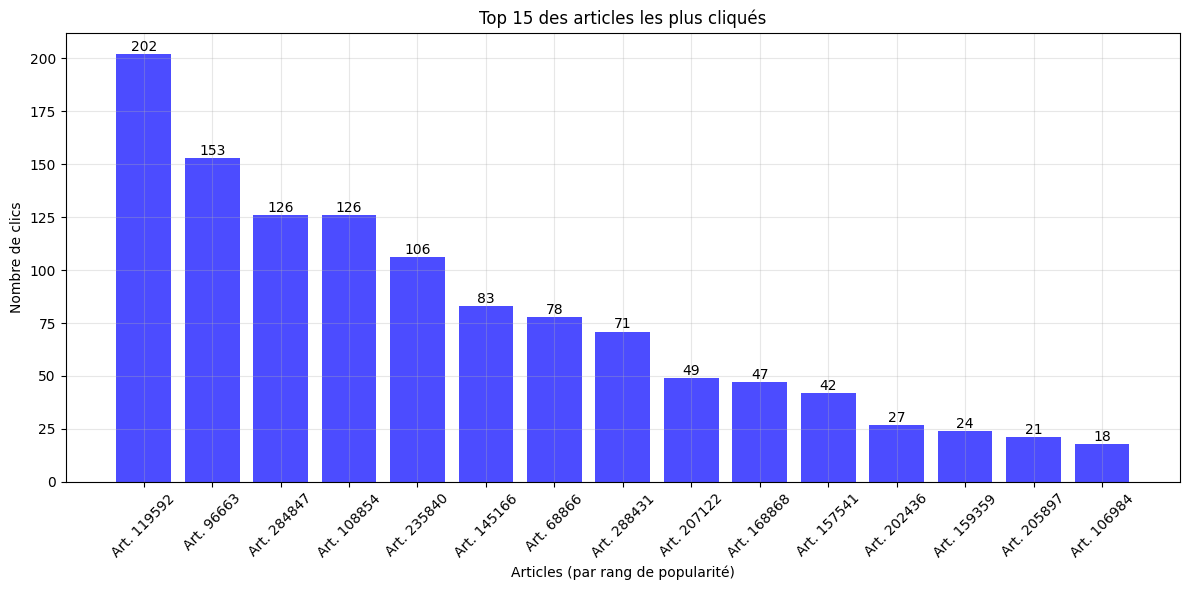

📊 Top 5 des articles les plus cliqués:
  1. Article 119592: 202 clics
  2. Article 96663: 153 clics
  3. Article 284847: 126 clics
  4. Article 108854: 126 clics
  5. Article 235840: 106 clics

Note explicite : La courte durée temporelle du dataset (47h35min) rend les patterns temporels peu exploitables.


In [12]:
print("\n📈 Visualisation 2: Articles les plus populaires")
article_popularity = clicks_df['click_article_id'].value_counts().head(15)
plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(article_popularity)), article_popularity.values, color='blue', alpha=0.7)
plt.xlabel("Articles (par rang de popularité)")
plt.ylabel("Nombre de clics")
plt.title("Top 15 des articles les plus cliqués")
plt.xticks(range(len(article_popularity)), [f'Art. {id}' for id in article_popularity.index], rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05, f'{int(height)}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"📊 Top 5 des articles les plus cliqués:")
for i, (article_id, count) in enumerate(article_popularity.head().items(), 1):
    print(f"  {i}. Article {article_id}: {count} clics")
    
print("\nNote explicite : La courte durée temporelle du dataset (47h35min) rend les patterns temporels peu exploitables.")


### 🔍 Analyse du contexte utilisateur (Appareils, Trafic, Géographie)
Afin de mieux comprendre comment notre application MVP sera utilisée, explorons les variables de contexte de nos lecteurs (sur quels appareils lisent-ils, d'où viennent-ils, etc.).

In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("\n📈 Visualisation contextuelle des clics")

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Taille des sessions (nb articles)",
        "Appareils utilisés (Device Group)",
        "Environnement du clic",
        "Source de trafic (Referrer)",
        "Systèmes d'exploitation (OS)",
        "Top 10 Pays"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

# 1. Session size (Histogram)
# On dédoublonne par session_id pour ne pas sur-compter les longues sessions
session_sizes = clicks_df.drop_duplicates('session_id')['session_size']
fig.add_trace(go.Histogram(
    x=session_sizes,
    nbinsx=15,
    marker_color='#1f77b4',
    name='Taille session'
), row=1, col=1)

# 2. Device Group
device_counts = clicks_df['click_deviceGroup'].value_counts()
fig.add_trace(go.Bar(
    x=[str(x) for x in device_counts.index],
    y=device_counts.values,
    marker_color='#ff7f0e',
    name='Devices'
), row=1, col=2)

# 3. Environment
env_counts = clicks_df['click_environment'].value_counts()
fig.add_trace(go.Bar(
    x=[str(x) for x in env_counts.index],
    y=env_counts.values,
    marker_color='#2ca02c',
    name='Environnement'
), row=1, col=3)

# 4. Referrer type
ref_counts = clicks_df['click_referrer_type'].value_counts()
fig.add_trace(go.Bar(
    x=[str(x) for x in ref_counts.index],
    y=ref_counts.values,
    marker_color='#d62728',
    name='Referrer'
), row=2, col=1)

# 5. OS
os_counts = clicks_df['click_os'].value_counts().head(10)
fig.add_trace(go.Bar(
    x=[str(x) for x in os_counts.index],
    y=os_counts.values,
    marker_color='#9467bd',
    name='OS'
), row=2, col=2)

# 6. Country (Top 10)
country_counts = clicks_df['click_country'].value_counts().head(10)
fig.add_trace(go.Bar(
    x=[str(x) for x in country_counts.index],
    y=country_counts.values,
    marker_color='#8c564b',
    name='Pays'
), row=2, col=3)

# Update layout
fig.update_layout(
    height=700, width=1200, 
    template="plotly_white", 
    showlegend=False,
    title_text="Analyse du contexte des clics (Appareils, Géographie, Trafic)"
)

# Set categorical axes
fig.update_xaxes(type='category', row=1, col=2)
fig.update_xaxes(type='category', row=1, col=3)
fig.update_xaxes(type='category', row=2, col=1)
fig.update_xaxes(type='category', row=2, col=2)
fig.update_xaxes(type='category', row=2, col=3)

fig.show()

print("📝 Note : Les variables contextuelles de Globo.com sont anonymisées (encodées avec des identifiants comme 'Pays 1', 'OS 17').")
print("Cependant, les pics révèlent de fortes hégémonies : un appareil, un environnement, un pays et une source de trafic dominent très largement !")



📈 Visualisation contextuelle des clics


📝 Note : Les variables contextuelles de Globo.com sont anonymisées (encodées avec des identifiants comme 'Pays 1', 'OS 17').
Cependant, les pics révèlent de fortes hégémonies : un appareil, un environnement, un pays et une source de trafic dominent très largement !


## 2. Sur `articles_metadata.csv` (métadonnées articles)


In [14]:
print(f"\n📰 ARTICLES METADATA:")
print(f"Shape: {articles_df.shape}")
print(f"Colonnes: {list(articles_df.columns)}")



📰 ARTICLES METADATA:
Shape: (364047, 5)
Colonnes: ['article_id', 'category_id', 'created_at_ts', 'publisher_id', 'words_count']


### 📝 Dictionnaire des variables (`articles_metadata.csv`)
- **`article_id`** : Identifiant unique de l'article (permet la jointure avec les clics).
- **`category_id`** : Identifiant de la catégorie ou de la thématique de l'article.
- **`created_at_ts`** : Heure exacte (timestamp en millisecondes) de la date de création / publication de l'article.
- **`publisher_id`** : Identifiant de l'éditeur de l'article.
- **`words_count`** : Longueur de l'article exprimée en nombre de mots.


In [18]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("📈 Visualisation 3: Analyse des métadonnées")

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Top 10 des catégories d'articles",
        "Distribution du nombre de mots par article",
        "Top 10 des éditeurs",
        "Historique de publication des articles"
    ),
    vertical_spacing=0.2,
    horizontal_spacing=0.1
)

# 1. Top 10 categories
category_counts = articles_df['category_id'].value_counts().head(10)
fig.add_trace(go.Bar(
    x=[str(cat) for cat in category_counts.index], 
    y=category_counts.values,
    marker_color='#9467bd',
    opacity=0.8,
    name='Catégories'
), row=1, col=1)

# 2. Distribution du nombre de mots
words_count = articles_df['words_count']
percentile_threshold = 99
bin_size = 50
threshold_value = np.percentile(words_count, percentile_threshold)
max_regular_bin = int(threshold_value // bin_size) * bin_size
bins = list(range(0, max_regular_bin + bin_size, bin_size))
bins.append(words_count.max())

labels = []
for i in range(len(bins) - 1):
    start = bins[i]
    if i == len(bins) - 2:
        labels.append(f'{start}+')
    else:
        end = bins[i+1] - 1
        labels.append(f'{start}-{end}')

words_categorized = pd.cut(words_count, bins=bins, labels=labels, include_lowest=True)
category_counts_words = words_categorized.value_counts().sort_index()

fig.add_trace(go.Bar(
    x=labels, 
    y=category_counts_words.values,
    marker_color='#ff7f0e',
    opacity=0.8,
    name='Nombre de mots'
), row=1, col=2)

# Calcul des quartiles
q1 = np.percentile(words_count, 25)
median = np.percentile(words_count, 50)
q3 = np.percentile(words_count, 75)

# Fonction pour trouver la coordonnée x dans Plotly (axe catégoriel)
def get_x_pos(val, bin_size=50):
    bin_idx = val // bin_size
    relative_pos = (val % bin_size) / bin_size
    return bin_idx - 0.5 + relative_pos

fig.add_vline(x=get_x_pos(q1), line_dash="dot", line_color="green", 
              annotation_text=f"Q1: {q1:.0f}", annotation_position="top left", row=1, col=2)
fig.add_vline(x=get_x_pos(median), line_dash="dash", line_color="blue", 
              annotation_text=f"Méd: {median:.0f}", annotation_position="top right", row=1, col=2)
fig.add_vline(x=get_x_pos(q3), line_dash="dot", line_color="green", 
              annotation_text=f"Q3: {q3:.0f}", annotation_position="top right", row=1, col=2)

# 3. Top 10 publishers
publisher_counts = articles_df['publisher_id'].value_counts().head(10)
fig.add_trace(go.Bar(
    x=[str(pub) for pub in publisher_counts.index], 
    y=publisher_counts.values,
    marker_color='#17becf',
    opacity=0.8,
    name='Éditeurs'
), row=2, col=1)

# 4. Articles by year
articles_df['year'] = pd.to_datetime(articles_df['created_at_ts'], unit='ms').dt.year
year_counts = articles_df['year'].value_counts().sort_index()
fig.add_trace(go.Scatter(
    x=year_counts.index, 
    y=year_counts.values,
    mode='lines+markers',
    marker=dict(size=8, color='#d62728'),
    line=dict(width=2, color='#d62728'),
    name='Année'
), row=2, col=2)

fig.update_xaxes(title_text="Category ID", type='category', row=1, col=1)
fig.update_yaxes(title_text="Nombre d'articles", row=1, col=1)

fig.update_xaxes(title_text=f"Nombre de mots (tranches de {bin_size})", row=1, col=2)
fig.update_yaxes(title_text="Nombre d'articles", row=1, col=2)

fig.update_xaxes(title_text="Publisher ID", type='category', row=2, col=1)
fig.update_yaxes(title_text="Nombre d'articles", row=2, col=1)

fig.update_xaxes(title_text="Année de publication", row=2, col=2)
fig.update_yaxes(title_text="Nombre d'articles", row=2, col=2)

fig.update_layout(height=800, width=1200, template="plotly_white", showlegend=False)
fig.show()

print(f"📊 Statistiques des métadonnées:")
print(f"- Catégories uniques: {articles_df['category_id'].nunique()}")
print(f"- Éditeurs uniques: {articles_df['publisher_id'].nunique()}")
print(f"- Nombre de mots médian: {articles_df['words_count'].median():.0f}")
print(f"- Période de publication: {articles_df['year'].min()} - {articles_df['year'].max()}")


📈 Visualisation 3: Analyse des métadonnées


📊 Statistiques des métadonnées:
- Catégories uniques: 461
- Éditeurs uniques: 1
- Nombre de mots médian: 186
- Période de publication: 2006 - 2018


### 📈 Analyse de la Longue Traîne (Courbe de Pareto des catégories)
Il est intéressant de voir si une petite portion des catégories représente la majorité des articles du catalogue.

In [19]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculer les comptes et pourcentages
category_counts = articles_df['category_id'].value_counts()
category_counts_df = category_counts.to_frame(name='count').reset_index()

# Calcul de la somme cumulée et du pourcentage cumulé
category_counts_df['cumulative_count'] = category_counts_df['count'].cumsum()
category_counts_df['cumulative_percent'] = 100 * category_counts_df['cumulative_count'] / category_counts_df['count'].sum()

# Créer la figure avec axe Y secondaire
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=[str(x) for x in category_counts_df['category_id']],
        y=category_counts_df['count'],
        name="Nombre d'articles",
        marker_color='#9467bd',
        opacity=0.7
    ),
    secondary_y=False,
)

# Ajouter la ligne cumulative
fig.add_trace(
    go.Scatter(
        x=[str(x) for x in category_counts_df['category_id']],
        y=category_counts_df['cumulative_percent'],
        name="Pourcentage cumulé (%)",
        line=dict(color='#d62728', width=3)
    ),
    secondary_y=True,
)

# Ajouter une ligne pour les 80%
fig.add_hline(y=80, line_dash="dash", line_color="green", secondary_y=True,
              annotation_text="Seuil des 80%", annotation_position="top right")

# Mise en page
fig.update_layout(
    title_text="Courbe de Pareto des catégories d'articles",
    xaxis_title="Category ID (trié par ordre de popularité)",
    height=500, width=1000,
    template="plotly_white",
    showlegend=False
)

fig.update_yaxes(title_text="Nombre d'articles", secondary_y=False)
fig.update_yaxes(title_text="Pourcentage cumulé (%)", range=[0, 105], secondary_y=True)

# Pour éviter d'afficher 461 labels sur l'axe X, on cache certains labels
fig.update_xaxes(showticklabels=False)

fig.show()

# Conclusion
num_categories_80 = len(category_counts_df[category_counts_df['cumulative_percent'] <= 80])
total_categories = len(category_counts_df)
print(f"📊 Constat : {num_categories_80} catégories (sur {total_categories} au total) concentrent à elles seules 80% du catalogue d'articles.")


📊 Constat : 67 catégories (sur 461 au total) concentrent à elles seules 80% du catalogue d'articles.


## 3. Matrice user–item et sparsité


### 📖 Définitions fondamentales

**1. La Matrice User-Item (Utilisateur-Article)**
C'est un tableau à double entrée fondamental dans les systèmes de recommandation. Chaque ligne représente un utilisateur unique, et chaque colonne représente un article unique du catalogue. À l'intersection des deux, on inscrit une valeur (ex: `1` s'il y a eu un clic, `0` sinon). Elle permet de modéliser mathématiquement l'historique complet des intéractions.

**2. La Sparsité (Densitié de la matrice)**
La sparsité désigne le pourcentage de « cases vides » dans cette matrice. Dans la vraie vie, un utilisateur ne lira qu'une infime fraction des articles disponibles. Si une matrice a une sparsité de 99%, cela signifie que 99% des combinaisons possibles *Utilisateur/Article* n'ont jamais eu lieu. Une sparsité trop élevée empêche le bon fonctionnement des algorithmes classiques basés sur le comportement (comme le Filtrage Collaboratif), car il n'y a pas assez de points communs comportementaux entre les utilisateurs.

In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

print("📈 Visualisation 4: Sparsité des données")
user_article_sample = clicks_df.groupby(['user_id', 'click_article_id']).size().unstack(fill_value=0)
top_articles = clicks_df['click_article_id'].value_counts().head(50).index
sample_users = user_article_sample.index[:50]
sample_matrix = user_article_sample.loc[sample_users, user_article_sample.columns.intersection(top_articles)]

total_cells = user_article_sample.shape[0] * user_article_sample.shape[1]
non_zero_cells = np.count_nonzero(user_article_sample.values)
sparsity = (1 - non_zero_cells / total_cells) * 100

labels = ['Cellules non-nulles', 'Cellules nulles (sparsité)']
sizes = [non_zero_cells, total_cells - non_zero_cells]
colors = ['#7367F0', '#E2E2E2']

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "domain"}]],
    subplot_titles=(
        'Heatmap user-article (échantillon 50x50)', 
        f'Sparsité de la matrice ({sparsity:.2f}% vides)'
    ),
    horizontal_spacing=0.15
)

fig.add_trace(
    go.Heatmap(
        z=sample_matrix.values,
        colorscale=[[0, '#E2E2E2'], [1, '#7367F0']],
        showscale=True,
        colorbar=dict(title='Nombre de clics', x=0.42)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=labels, 
        values=sizes, 
        marker_colors=colors,
        textinfo='label+percent',
        hole=0.4
    ),
    row=1, col=2
)

fig.update_xaxes(title_text='Articles (échantillon)', row=1, col=1)
fig.update_yaxes(title_text='Utilisateurs (échantillon)', row=1, col=1)

fig.update_layout(height=500, width=1100, template="plotly_white", showlegend=False)
fig.show()

print(f"📊 Métriques de sparsité:")
print(f"- Matrice user-article: {user_article_sample.shape}")
print(f"- Cellules totales: {total_cells:,}")
print(f"- Cellules non-nulles: {non_zero_cells:,}")
print(f"- Sparsité: {sparsity:.2f}%")

print(f"🎯 Explication de la sparsité dans les systèmes de recommandation :")
print("La sparsité représente le pourcentage d'interactions non existantes (utilisateurs n'ayant pas lu un article spécifique).")
print(f"Une sparsité de {sparsity:.2f}% indique qu'il est difficile d'utiliser uniquement du Collaborative Filtering (filtrage collaboratif)")
print("et qu'une approche Content-Based (basée sur les métadonnées et embeddings des articles) est souvent nécessaire pour pallier au cold start.")


📈 Visualisation 4: Sparsité des données


📊 Métriques de sparsité:
- Matrice user-article: (707, 323)
- Cellules totales: 228,361
- Cellules non-nulles: 1,883
- Sparsité: 99.18%
🎯 Explication de la sparsité dans les systèmes de recommandation :
La sparsité représente le pourcentage d'interactions non existantes (utilisateurs n'ayant pas lu un article spécifique).
Une sparsité de 99.18% indique qu'il est difficile d'utiliser uniquement du Collaborative Filtering (filtrage collaboratif)
et qu'une approche Content-Based (basée sur les métadonnées et embeddings des articles) est souvent nécessaire pour pallier au cold start.


## 4. Alignement des données et embeddings

In [28]:
print(f"\n🔗 Vérification de l'alignement des données:")
print(f"- Nombre d'articles dans articles_df: {len(articles_df)}")
print(f"- Nombre d'embeddings: {embeddings.shape[0]}")

max_article_id = articles_df['article_id'].max()
min_article_id = articles_df['article_id'].min()
print(f"- Range article_id: {min_article_id} à {max_article_id}")

if max_article_id == embeddings.shape[0] - 1 and min_article_id == 0:
    print("✅ Alignement article_id <-> index des embeddings confirmé")
else:
    print("⚠️ Vérifier l'alignement article_id <-> embeddings")

print(f"\nAnalyse des embeddings pour le content-based :")
print(f"- Shape des embeddings: {embeddings.shape}")
print(f"- Type des données: {embeddings.dtype}")
print(f"- Valeurs nulles: {np.isnan(embeddings).sum()}")
print(f"- Range des valeurs (min, max): ({embeddings.min():.4f}, {embeddings.max():.4f})")



🔗 Vérification de l'alignement des données:
- Nombre d'articles dans articles_df: 364047
- Nombre d'embeddings: 364047
- Range article_id: 0 à 364046
✅ Alignement article_id <-> index des embeddings confirmé

Analyse des embeddings pour le content-based :
- Shape des embeddings: (364047, 250)
- Type des données: float32
- Valeurs nulles: 0
- Range des valeurs (min, max): (-0.9987, 0.9984)


Il y a autant de lignes dans la matrice que d'articles dans le catalogue (364 047 dans les deux cas).

## 5. Préparation des structures pour les modèles (partie analyse pour modélisation)


In [30]:
print(f"\n🛠️ Construction du dictionnaire des interactions")
user_articles_dict = clicks_df.groupby('user_id')['click_article_id'].apply(list).to_dict()
articles_per_user = [len(articles) for articles in user_articles_dict.values()]

print("Statistiques 'nombre d'articles cliqués par utilisateur':")
print(f"- Min: {np.min(articles_per_user)}")
print(f"- Médiane: {np.median(articles_per_user)}")
print(f"- Moyenne: {np.mean(articles_per_user):.2f}")
print(f"- Max: {np.max(articles_per_user)}")



🛠️ Construction du dictionnaire des interactions
Statistiques 'nombre d'articles cliqués par utilisateur':
- Min: 2
- Médiane: 2.0
- Moyenne: 2.66
- Max: 24


In [35]:
print(f"\n🛠️ Matrice user-item pour le Collaborative Filtering")
user_item_matrix = clicks_df.groupby(['user_id', 'click_article_id']).size().reset_index(name='clicks')
print("Distribution des 'ratings' implicites (nombre de clics) :")
display(user_item_matrix['clicks'].describe())



🛠️ Matrice user-item pour le Collaborative Filtering
Distribution des 'ratings' implicites (nombre de clics) :


count    1883.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: clicks, dtype: float64

## 6. Réduction de Dimension (PCA) sur les Embeddings



Application de l'ACP pour conserver 95.0% de la variance...
Dimension d'origine : 250
Nouvelle dimension après ACP : 52


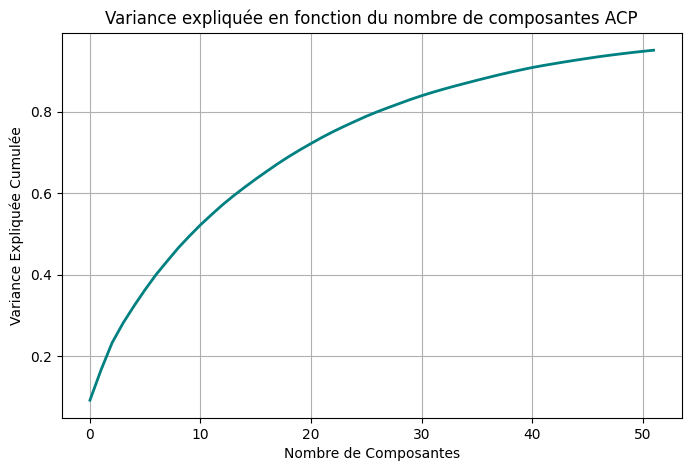


Sauvegarde des embeddings réduits dans ../Generated/articles_embeddings_pca.pickle...
Sauvegarde terminée !


In [36]:
def apply_pca(embeddings, variance_target=0.95):
    print(f"\nApplication de l'ACP pour conserver {variance_target*100}% de la variance...")
    pca = PCA(n_components=variance_target)
    embeddings_reduced = pca.fit_transform(embeddings)
    
    print(f"Dimension d'origine : {embeddings.shape[1]}")
    print(f"Nouvelle dimension après ACP : {embeddings_reduced.shape[1]}")
    
    # Affichage de la variance expliquée
    plt.figure(figsize=(8, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), color='teal', linewidth=2)
    plt.xlabel('Nombre de Composantes')
    plt.ylabel('Variance Expliquée Cumulée')
    plt.title('Variance expliquée en fonction du nombre de composantes ACP')
    plt.grid(True)
    plt.show()
    
    return embeddings_reduced, pca

def save_reduced_embeddings(embeddings_reduced):
    print(f"\nSauvegarde des embeddings réduits dans {OUTPUT_EMBEDDINGS_PATH}...")
    with open(OUTPUT_EMBEDDINGS_PATH, 'wb') as f:
        pickle.dump(embeddings_reduced, f)
    print("Sauvegarde terminée !")

embeddings_reduced, pca_model = apply_pca(embeddings)
save_reduced_embeddings(embeddings_reduced)
